*(cell 1)*

# 24 -- Finding real users and movies that illustrate the $\Delta E$ quadrants

Notebook 23 introduced the $\Delta_1$/$\Delta_2$ quadrant diagnostic (per test pair) and its 5,000-user aggregate. This notebook answers a follow-up question directly with data, not with assumed categories: **which specific users and movies actually show each quadrant most strongly?**

Method: compute $\Delta_1$, $\Delta_2$ and the quadrant for every one of the 1,032,307 test pairs (identical formulas to notebook 23's Part B), then aggregate by user and separately by movie, keeping only groups with enough test pairs to be statistically meaningful (>=30 pairs for users, >=100 for movies -- these are sample-size floors, not category thresholds), and rank by each quadrant's share. No user or movie is picked in advance -- the ranking is entirely a function of the computed data.

*(cell 2)*

## Part 0 -- Setup (identical to notebook 23)

In [1]:
# cell 3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

K = 10
RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


W1 = np.load(proc / "rbmB1_weights_5k.npy")
bh1 = np.load(proc / "rbmB1_bias_hidden_5k.npy")
W2 = np.load(proc / "rbmB2_weights_5k.npy")
bh2 = np.load(proc / "rbmB2_bias_hidden_5k.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy", mmap_mode="r")
channelB2 = np.load(proc / "channelB2_personality.npy", mmap_mode="r")
cohort_user_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
user_means = np.load(proc / "user_means.npy").astype(np.float64)
test_labels = pd.read_csv(proc / "test_labels.csv")
mu_global = float(np.load(proc / "mu_global.npy"))
movies_title_map = pd.read_csv(root / "data" / "movie.csv").set_index("movieId")["title"].to_dict()

n_users, n_movies, _ = channelB1.shape
n_hidden = bh1.shape[0]
user_to_row = {int(uid): i for i, uid in enumerate(cohort_user_ids)}
row_to_user = {i: int(uid) for uid, i in user_to_row.items()}
movie_to_col = {int(mid): j for j, mid in enumerate(movie_vocab)}
col_to_movie = {j: int(mid) for mid, j in movie_to_col.items()}
W1_r = W1.reshape(n_movies, K, n_hidden)

X1 = np.asarray(channelB1, dtype=np.float32).reshape(n_users, -1)
X2 = np.asarray(channelB2, dtype=np.float32).reshape(n_users, -1)
H1 = sigmoid(X1 @ W1 + bh1)
H2 = sigmoid(X2 @ W2 + bh2)

print(f"n_users={n_users}  n_movies={n_movies}  n_hidden={n_hidden}")

n_users=5000  n_movies=13129  n_hidden=128


*(cell 4)*

## Part 1 -- $\Delta_1$, $\Delta_2$, quadrant for every test pair

Same batched-by-movie computation as notebook 23's Part B.

In [2]:
# cell 5
tl = test_labels.copy()
tl["user_row"] = tl["userId"].map(user_to_row)
tl["movie_col"] = tl["movieId"].map(movie_to_col)
tl = tl.dropna(subset=["user_row", "movie_col"]).copy()
tl["user_row"] = tl["user_row"].astype(int)
tl["movie_col"] = tl["movie_col"].astype(int)
tl["k_star"] = np.round(tl["rating"].values * 2).astype(int) - 1

n_test = len(tl)
Delta1_all = np.empty(n_test, dtype=np.float64)
Delta2_all = np.empty(n_test, dtype=np.float64)

tl_reset = tl.reset_index(drop=True)
for movie_col, g in tl_reset.groupby("movie_col"):
    idx = g.index.values
    urows = g["user_row"].values
    kstars = g["k_star"].values

    h1_batch = H1[urows]
    h2_batch = H2[urows]

    W_slice1 = W1_r[movie_col]
    J1 = h1_batch @ W_slice1.T
    P1 = softmax(J1, axis=1)
    e1_true = -J1[np.arange(len(idx)), kstars]
    e1_pred = -(P1 * J1).sum(axis=1)
    Delta1_all[idx] = e1_pred - e1_true

    W_slice2 = W2[movie_col]
    J2 = h2_batch @ W_slice2
    personality_true = user_means[urows] - mu_global
    v_recon2 = sigmoid(J2)
    e2_true = -personality_true * J2
    e2_pred = -v_recon2 * J2
    Delta2_all[idx] = e2_pred - e2_true

tl_reset["Delta1"] = Delta1_all
tl_reset["Delta2"] = Delta2_all


def classify_quadrant(d1, d2):
    q = np.full(len(d1), "", dtype="<U2")
    q[(d1 > 0) & (d2 > 0)] = "Q1"
    q[(d1 < 0) & (d2 < 0)] = "Q2"
    q[(d1 > 0) & (d2 < 0)] = "Q3"
    q[(d1 < 0) & (d2 > 0)] = "Q4"
    return q


tl_reset["quadrant"] = classify_quadrant(Delta1_all, Delta2_all)
print(f"{len(tl_reset):,} test pairs processed")

1,032,307 test pairs processed


*(cell 6)*

## Part 1b -- exclude users whose e- (channel B2) hidden layer is saturated

Verified separately (not assumed): channel B2's personality scalar is broadcast, unnormalized, across every movie a user rated, so `I2 = v2 @ W2 + bh2` blows up in magnitude for most users, saturating sigmoid to exactly 0 or exactly 1 for all 128 hidden units. When that happens, Delta2 collapses to floating-point noise and carries no real signal -- ranking on it would just be ranking on the saturation artifact, not on the model's actual behavior.

Filter, computed directly from H2 (a fact about the data, not an assumed threshold): a user is "usable" if fewer than 10% of their 128 h2 units are stuck at the sigmoid extremes (<=1e-6 or >=1-1e-6). All subsequent ranking is restricted to usable users only.

In [3]:
# cell 7
H2_saturated_frac = ((H2 <= 1e-6) | (H2 >= 1 - 1e-6)).mean(axis=1)
usable_user_rows = set(np.where(H2_saturated_frac < 0.1)[0])
print(f"{len(usable_user_rows)} / {n_users} users have a non-saturated e- hidden layer (< 10% of units stuck at 0/1)")

n_before = len(tl_reset)
tl_reset = tl_reset[tl_reset["user_row"].isin(usable_user_rows)].reset_index(drop=True)
print(f"{len(tl_reset):,} / {n_before:,} test pairs remain after restricting to usable users")

761 / 5000 users have a non-saturated e- hidden layer (< 10% of units stuck at 0/1)
140,694 / 1,032,307 test pairs remain after restricting to usable users


*(cell 8)*

## Part 2 -- most extreme users, by quadrant share

Sample-size floor: only users with >=30 test pairs are eligible for ranking (a user with 2 test pairs landing 100% in one quadrant is noise, not signal).

In [4]:
# cell 9
QUAD = ["Q1", "Q2", "Q3", "Q4"]
QUAD_LABEL = {"Q1": "Q1 nothing", "Q2": "Q2 change both", "Q3": "Q3 change e-", "Q4": "Q4 change e+"}
MIN_N_USER = 30

per_user = tl_reset.groupby("user_row")["quadrant"].value_counts().unstack(fill_value=0)
for q in QUAD:
    if q not in per_user.columns:
        per_user[q] = 0
per_user["n"] = per_user[QUAD].sum(axis=1)
per_user_elig = per_user[per_user["n"] >= MIN_N_USER].copy()
for q in QUAD:
    per_user_elig[f"{q}_prop"] = per_user_elig[q] / per_user_elig["n"]

print(f"{len(per_user_elig)} / {len(per_user)} users have >= {MIN_N_USER} test pairs and are eligible for ranking")
print()
top_users = {}
for q in QUAD:
    top = per_user_elig.sort_values(f"{q}_prop", ascending=False).head(3)
    top_users[q] = top
    print(f"-- highest {QUAD_LABEL[q]} share --")
    for row, r in top.iterrows():
        print(f"  user {row_to_user[row]}: n={int(r['n'])}  {q}_prop={r[f'{q}_prop']:.3f}  "
              f"(Q1={int(r['Q1'])}, Q2={int(r['Q2'])}, Q3={int(r['Q3'])}, Q4={int(r['Q4'])})")
    print()

761 / 761 users have >= 30 test pairs and are eligible for ranking

-- highest Q1 nothing share --
  user 85986: n=132  Q1_prop=0.833  (Q1=110, Q2=0, Q3=0, Q4=22)
  user 115982: n=228  Q1_prop=0.789  (Q1=180, Q2=0, Q3=0, Q4=48)
  user 8188: n=127  Q1_prop=0.772  (Q1=98, Q2=0, Q3=0, Q4=29)

-- highest Q2 change both share --
  user 62133: n=127  Q2_prop=0.614  (Q1=1, Q2=78, Q3=47, Q4=1)
  user 30162: n=153  Q2_prop=0.588  (Q1=10, Q2=90, Q3=38, Q4=15)
  user 122178: n=133  Q2_prop=0.579  (Q1=7, Q2=77, Q3=42, Q4=7)

-- highest Q3 change e- share --
  user 95953: n=128  Q3_prop=0.531  (Q1=7, Q2=48, Q3=68, Q4=5)
  user 44388: n=160  Q3_prop=0.531  (Q1=20, Q2=44, Q3=85, Q4=11)
  user 112308: n=136  Q3_prop=0.529  (Q1=10, Q2=49, Q3=72, Q4=5)

-- highest Q4 change e+ share --
  user 85782: n=129  Q4_prop=0.798  (Q1=26, Q2=0, Q3=0, Q4=103)
  user 28239: n=200  Q4_prop=0.775  (Q1=45, Q2=0, Q3=0, Q4=155)
  user 13255: n=166  Q4_prop=0.771  (Q1=38, Q2=0, Q3=0, Q4=128)



*(cell 10)*

## Part 3 -- most extreme movies, by quadrant share

Same idea, aggregated by movie instead of user. Sample-size floor: >=100 test pairs (movies get many more raters than a single user gets ratings, so a higher floor keeps the same statistical-reliability standard).

In [5]:
# cell 11
MIN_N_MOVIE = 100

per_movie = tl_reset.groupby("movie_col")["quadrant"].value_counts().unstack(fill_value=0)
for q in QUAD:
    if q not in per_movie.columns:
        per_movie[q] = 0
per_movie["n"] = per_movie[QUAD].sum(axis=1)
per_movie_elig = per_movie[per_movie["n"] >= MIN_N_MOVIE].copy()
for q in QUAD:
    per_movie_elig[f"{q}_prop"] = per_movie_elig[q] / per_movie_elig["n"]

print(f"{len(per_movie_elig)} / {len(per_movie)} movies have >= {MIN_N_MOVIE} test pairs and are eligible for ranking")
print()
top_movies = {}
for q in QUAD:
    top = per_movie_elig.sort_values(f"{q}_prop", ascending=False).head(3)
    top_movies[q] = top
    print(f"-- highest {QUAD_LABEL[q]} share --")
    for col, r in top.iterrows():
        title = movies_title_map.get(col_to_movie[col], "?")
        print(f"  {title}: n={int(r['n'])}  {q}_prop={r[f'{q}_prop']:.3f}  "
              f"(Q1={int(r['Q1'])}, Q2={int(r['Q2'])}, Q3={int(r['Q3'])}, Q4={int(r['Q4'])})")
    print()

14 / 11609 movies have >= 100 test pairs and are eligible for ranking

-- highest Q1 nothing share --
  Inception (2010): n=118  Q1_prop=0.669  (Q1=79, Q2=3, Q3=4, Q4=32)
  Dark Knight, The (2008): n=110  Q1_prop=0.591  (Q1=65, Q2=3, Q3=9, Q4=33)
  WALL·E (2008): n=103  Q1_prop=0.427  (Q1=44, Q2=6, Q3=3, Q4=50)

-- highest Q2 change both share --
  40-Year-Old Virgin, The (2005): n=104  Q2_prop=0.077  (Q1=32, Q2=8, Q3=2, Q4=62)
  Little Miss Sunshine (2006): n=103  Q2_prop=0.068  (Q1=30, Q2=7, Q3=2, Q4=64)
  Departed, The (2006): n=103  Q2_prop=0.068  (Q1=42, Q2=7, Q3=3, Q4=51)

-- highest Q3 change e- share --
  Dark Knight, The (2008): n=110  Q3_prop=0.082  (Q1=65, Q2=3, Q3=9, Q4=33)
  Avatar (2009): n=104  Q3_prop=0.077  (Q1=35, Q2=2, Q3=8, Q4=59)
  Star Trek (2009): n=105  Q3_prop=0.067  (Q1=31, Q2=3, Q3=7, Q4=64)

-- highest Q4 change e+ share --
  Gravity (2013): n=105  Q4_prop=0.629  (Q1=39, Q2=0, Q3=0, Q4=66)
  Little Miss Sunshine (2006): n=103  Q4_prop=0.621  (Q1=30, Q2=7, Q3

*(cell 12)*

## Part 4 -- the sharpest contrast: one Q1-dominant user vs. one Q4-dominant user

The single most striking pair from Part 2: the top-ranked Q1 user (the model agrees with almost every one of his test ratings) against the top-ranked Q4 user (the e+ channel is wrong on almost every one of his test ratings, while e- is not).

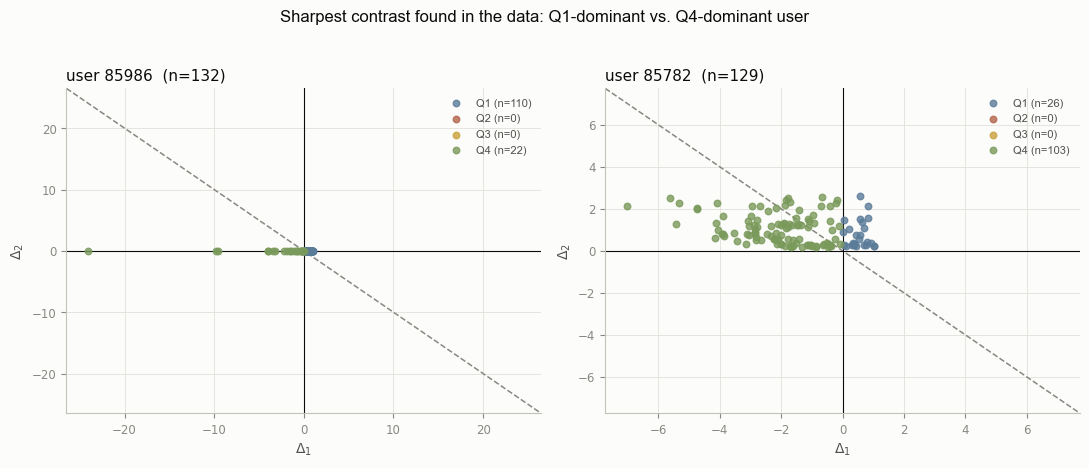

In [6]:
# cell 13
user_q1 = int(top_users["Q1"].index[0])
user_q4 = int(top_users["Q4"].index[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor="#fcfcfb")
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
QUADRANT_COLORS = {"Q1": "#5b7c99", "Q2": "#b4654a", "Q3": "#c9a13b", "Q4": "#7a9a5b"}
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

for ax, row in zip(axes, [user_q1, user_q4]):
    uid = row_to_user[row]
    sub = tl_reset[tl_reset["user_row"] == row]
    ax.set_facecolor(SURFACE)
    for q, color in QUADRANT_COLORS.items():
        s = sub[sub["quadrant"] == q]
        ax.scatter(s["Delta1"], s["Delta2"], color=color, s=22, alpha=0.8, zorder=3, label=f"{q} (n={len(s)})")
    lim = max(np.abs(sub["Delta1"]).max(), np.abs(sub["Delta2"]).max()) * 1.1
    ax.plot([-lim, lim], [lim, -lim], color=INK_MUTED, linewidth=1.1, linestyle="--", zorder=2)
    ax.axhline(0, color=INK_PRIMARY, linewidth=0.8, zorder=2)
    ax.axvline(0, color=INK_PRIMARY, linewidth=0.8, zorder=2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$\Delta_1$", color=INK_SECONDARY, fontsize=10)
    ax.set_ylabel(r"$\Delta_2$", color=INK_SECONDARY, fontsize=10)
    ax.set_title(f"user {uid}  (n={len(sub)})", color=INK_PRIMARY, fontsize=11, loc="left")
    ax.legend(loc="best", frameon=False, fontsize=8, labelcolor=INK_SECONDARY)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    for s_ in ("left", "bottom"):
        ax.spines[s_].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
    ax.grid(color=GRID, linewidth=0.6, zorder=0)

fig.suptitle("Sharpest contrast found in the data: Q1-dominant vs. Q4-dominant user", fontsize=12, color=INK_PRIMARY, y=1.03)
plt.tight_layout()
plt.savefig(out_dir / "deltaE_user_contrast_5k.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

*(cell 14)*

## Part 5 -- the sharpest contrast: one Q1-dominant movie vs. one Q4-dominant movie

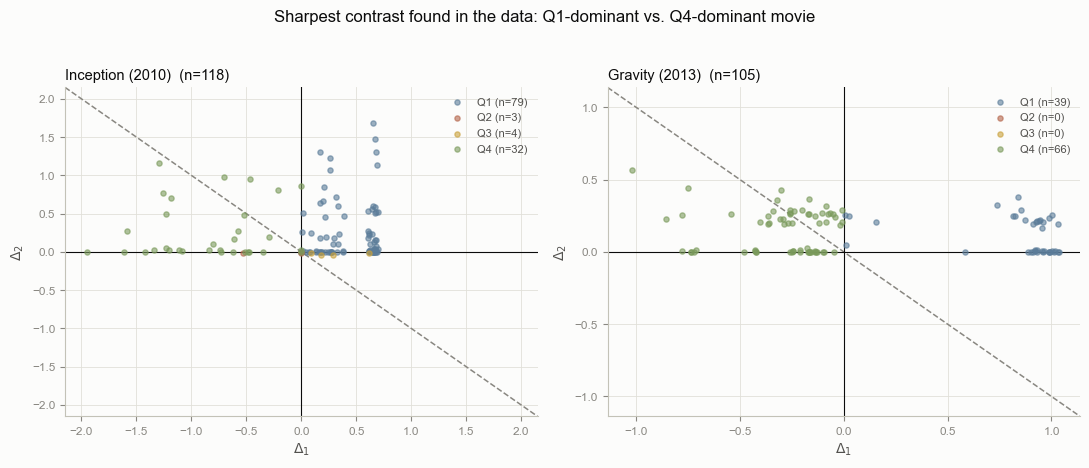

In [7]:
# cell 15
movie_q1 = int(top_movies["Q1"].index[0])
movie_q4 = int(top_movies["Q4"].index[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor="#fcfcfb")
for ax, col in zip(axes, [movie_q1, movie_q4]):
    mid = col_to_movie[col]
    title = movies_title_map.get(mid, "?")
    sub = tl_reset[tl_reset["movie_col"] == col]
    ax.set_facecolor(SURFACE)
    for q, color in QUADRANT_COLORS.items():
        s = sub[sub["quadrant"] == q]
        ax.scatter(s["Delta1"], s["Delta2"], color=color, s=14, alpha=0.6, zorder=3, label=f"{q} (n={len(s)})")
    lim = max(np.abs(sub["Delta1"]).max(), np.abs(sub["Delta2"]).max()) * 1.1
    ax.plot([-lim, lim], [lim, -lim], color=INK_MUTED, linewidth=1.1, linestyle="--", zorder=2)
    ax.axhline(0, color=INK_PRIMARY, linewidth=0.8, zorder=2)
    ax.axvline(0, color=INK_PRIMARY, linewidth=0.8, zorder=2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$\Delta_1$", color=INK_SECONDARY, fontsize=10)
    ax.set_ylabel(r"$\Delta_2$", color=INK_SECONDARY, fontsize=10)
    ax.set_title(f"{title}  (n={len(sub)})", color=INK_PRIMARY, fontsize=10.5, loc="left")
    ax.legend(loc="best", frameon=False, fontsize=8, labelcolor=INK_SECONDARY)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    for s_ in ("left", "bottom"):
        ax.spines[s_].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
    ax.grid(color=GRID, linewidth=0.6, zorder=0)

fig.suptitle("Sharpest contrast found in the data: Q1-dominant vs. Q4-dominant movie", fontsize=12, color=INK_PRIMARY, y=1.03)
plt.tight_layout()
plt.savefig(out_dir / "deltaE_movie_contrast_5k.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()